# Prophet model from facebook to be used in time series analysis

In [17]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [18]:
import pandas as pd

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df = pd.read_csv(url)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3650 non-null   object 
 1   Temp    3650 non-null   float64
dtypes: float64(1), object(1)
memory usage: 57.2+ KB


In [19]:
import pandas as pd

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"

df = pd.read_csv(url, index_col="Date", parse_dates=True)

print(df.head())
print(df.info())

            Temp
Date            
1981-01-01  20.7
1981-01-02  17.9
1981-01-03  18.8
1981-01-04  14.6
1981-01-05  15.8
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3650 entries, 1981-01-01 to 1990-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Temp    3650 non-null   float64
dtypes: float64(1)
memory usage: 57.0 KB
None


In [20]:
df.describe()

,Temp
count,3650.000000
mean,11.177753
std,4.071837
min,0.000000
25%,8.300000
50%,11.000000
75%,14.000000
max,26.300000


In [21]:
print(df.columns)

Index(['Temp'], dtype='object')


<Axes: xlabel='Date', ylabel='Temp'>

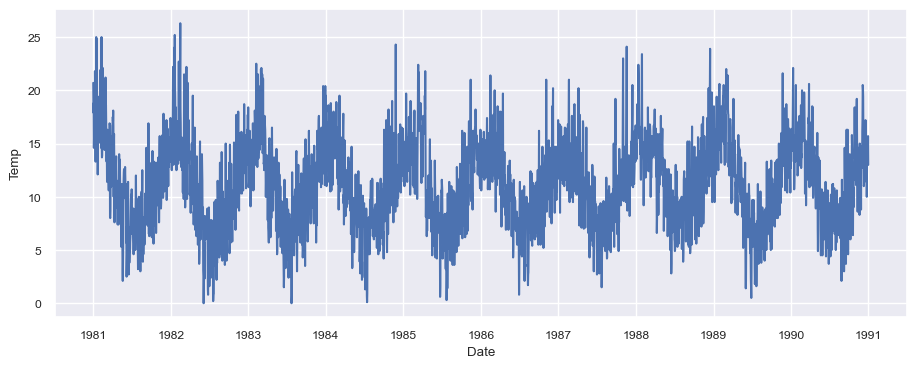

In [22]:
sns.set(rc={'figure.figsize':(11, 4)}, font_scale=0.8, style='darkgrid')

sns.lineplot(data=df, x=df.index, y="Temp")

In [24]:
fig = px.line(df, x=df.index, y="Temp", title='Temperature')
fig.show()

In [25]:
# interpolate the outliers from mean pressure column on 28.March.2016
df.loc['2016-03-28', 'meanpressure'] = np.nan
df['meanpressure'] = df['meanpressure'].interpolate(method='time')
df.loc['2016-03-28']



Temp           NaN
meanpressure   NaN
Name: 2016-03-28 00:00:00, dtype: float64

In [27]:
fig = px.scatter(df, x="Temp", y="meanpressure",
                 title='Temperature vs Pressure',
                 trendline="ols", trendline_color_override="red")
fig.show()

In [29]:
from scipy.stats import pearsonr

corr, _ = pearsonr(df['Temp'], df['meanpressure'])
print('Pearsons correlation: %.3f' % corr)

Pearsons correlation: nan


<Axes: >

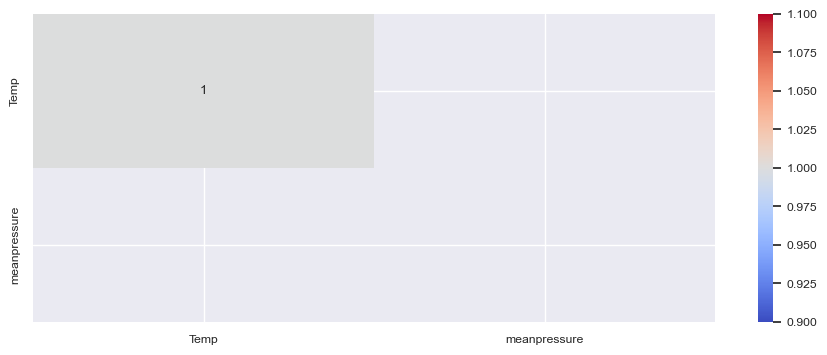

In [30]:
# make a heatmap of correlation
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')


In [31]:
# lets scale the data
from sklearn.preprocessing import MinMaxScaler,StandardScaler
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)
df_scaled.describe()

c:\Users\Abdullah\anaconda3\envs\python_ml\Lib\site-packages\sklearn\utils\extmath.py:1144: RuntimeWarning:

invalid value encountered in divide

c:\Users\Abdullah\anaconda3\envs\python_ml\Lib\site-packages\sklearn\utils\extmath.py:1149: RuntimeWarning:

invalid value encountered in divide

c:\Users\Abdullah\anaconda3\envs\python_ml\Lib\site-packages\sklearn\utils\extmath.py:1169: RuntimeWarning:

invalid value encountered in divide



,Temp,meanpressure
count,3.650000e+03,0.0
mean,-1.654689e-16,NaN
std,1.000137e+00,NaN
min,-2.745514e+00,NaN
25%,-7.068426e-01,NaN
50%,-4.366034e-02,NaN
75%,6.932088e-01,NaN
max,3.714372e+00,NaN


<Axes: >

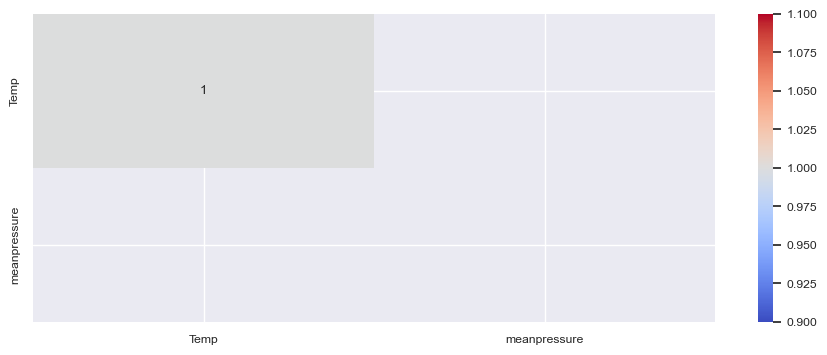

In [32]:
# make a correlation heatmap of scaled data
sns.heatmap(df_scaled.corr(), annot=True, cmap='coolwarm') # we wont see any change in correlation


In [35]:
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

<Axes: xlabel='Date', ylabel='Temp'>

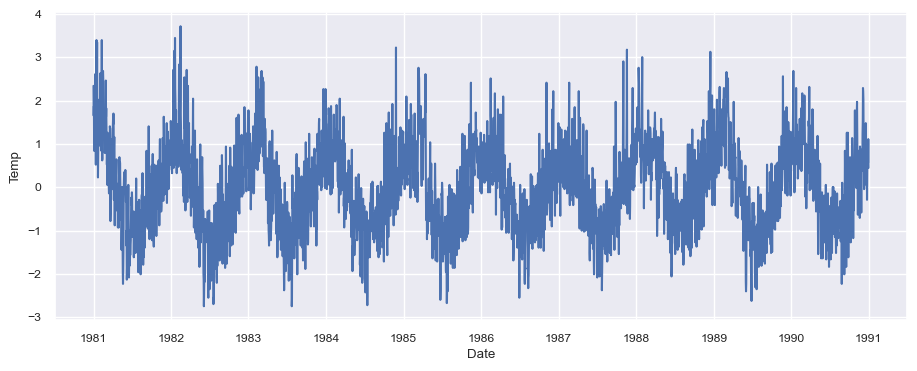

In [37]:
sns.set(rc={'figure.figsize':(11, 4)}, font_scale=0.8, style='darkgrid')

sns.lineplot(data=df_scaled, x=df_scaled.index, y="Temp")

In [38]:
# add two columns in the dataset for month and year
df_scaled['month'] = df_scaled.index.month
df_scaled['year'] = df_scaled.index.year
df_scaled.head()

,Temp,meanpressure,month,year
Date,,,,
1981-01-01,2.338883,NaN,1,1981
1981-01-02,1.651139,NaN,1,1981
1981-01-03,1.872199,NaN,1,1981
1981-01-04,0.840583,NaN,1,1981
1981-01-05,1.135330,NaN,1,1981


In [39]:
# add two columns in the dataset for month and year
df['month'] = df.index.month
df['year'] = df.index.year
df.head()

,Temp,meanpressure,month,year
Date,,,,
1981-01-01,20.7,NaN,1,1981
1981-01-02,17.9,NaN,1,1981
1981-01-03,18.8,NaN,1,1981
1981-01-04,14.6,NaN,1,1981
1981-01-05,15.8,NaN,1,1981


<Axes: xlabel='Date', ylabel='Temp'>

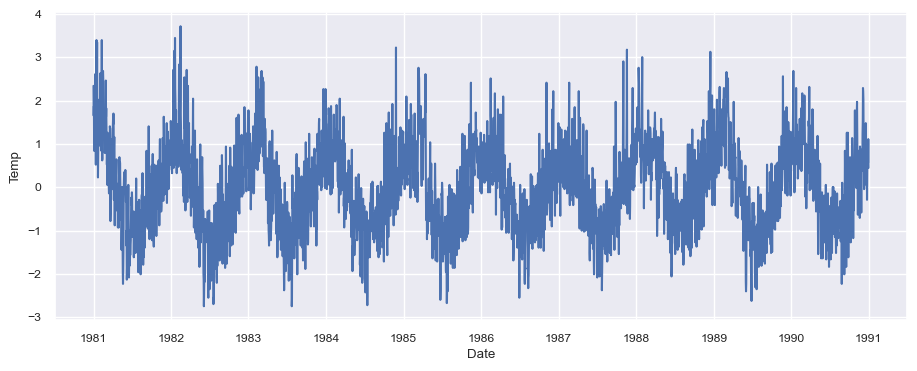

In [41]:
sns.lineplot(data=df_scaled, x=df_scaled.index, y="Temp")

In [43]:
fig = px.line(df_scaled, x=df_scaled.index, y="Temp",
              title='Temperature Over Time')
fig.show()

In [45]:
fig = px.line(df, x=df.index, y="Temp", color="year",
              title='Temperature by Year')
fig.show()

# lets use the prophet model from python

In [47]:
import pandas as pd

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"

df = pd.read_csv(url)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3650 non-null   object 
 1   Temp    3650 non-null   float64
dtypes: float64(1), object(1)
memory usage: 57.2+ KB


,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


In [50]:
print(df)

            Date  Temp
0     1981-01-01  20.7
1     1981-01-02  17.9
2     1981-01-03  18.8
3     1981-01-04  14.6
4     1981-01-05  15.8
...          ...   ...
3645  1990-12-27  14.0
3646  1990-12-28  13.6
3647  1990-12-29  13.5
3648  1990-12-30  15.7
3649  1990-12-31  13.0

[3650 rows x 2 columns]


In [52]:
!pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   -----------------

In [54]:
df.columns = ['ds', 'y']

In [55]:
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly

#call the model
model = Prophet()
model.fit(df)
forecast = model.make_future_dataframe(periods=365)
forecast = model.predict(forecast)
plot_plotly(model, forecast)

17:42:41 - cmdstanpy - INFO - Chain [1] start processing
17:42:44 - cmdstanpy - INFO - Chain [1] done processing


In [56]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1981-01-01,11.858863,11.630086,18.889604,11.858863,11.858863,3.328327,3.328327,3.328327,0.010955,0.010955,0.010955,3.317372,3.317372,3.317372,0.0,0.0,0.0,15.187190
1,1981-01-02,11.857024,11.847505,18.837057,11.857024,11.857024,3.375110,3.375110,3.375110,-0.019840,-0.019840,-0.019840,3.394950,3.394950,3.394950,0.0,0.0,0.0,15.232134
2,1981-01-03,11.855185,12.068705,18.721562,11.855185,11.855185,3.411932,3.411932,3.411932,-0.060118,-0.060118,-0.060118,3.472050,3.472050,3.472050,0.0,0.0,0.0,15.267117
3,1981-01-04,11.853347,12.195791,18.674254,11.853347,11.853347,3.394345,3.394345,3.394345,-0.153082,-0.153082,-0.153082,3.547427,3.547427,3.547427,0.0,0.0,0.0,15.247691
4,1981-01-05,11.851508,11.960592,18.551313,11.851508,11.851508,3.600153,3.600153,3.600153,-0.019706,-0.019706,-0.019706,3.619859,3.619859,3.619859,0.0,0.0,0.0,15.451661


In [57]:
# diagnose model fit on the training data
from sklearn.metrics import mean_absolute_error, mean_squared_error
y_true = df['y']
y_pred = forecast['yhat'][:len(df)]
print("MAE: ", mean_absolute_error(y_true, y_pred))
print("MSE: ", mean_squared_error(y_true, y_pred))
print("RMSE: ", np.sqrt(mean_squared_error(y_true, y_pred)))


MAE:  2.139226901992109
MSE:  7.327883000538909
RMSE:  2.7070062801070316


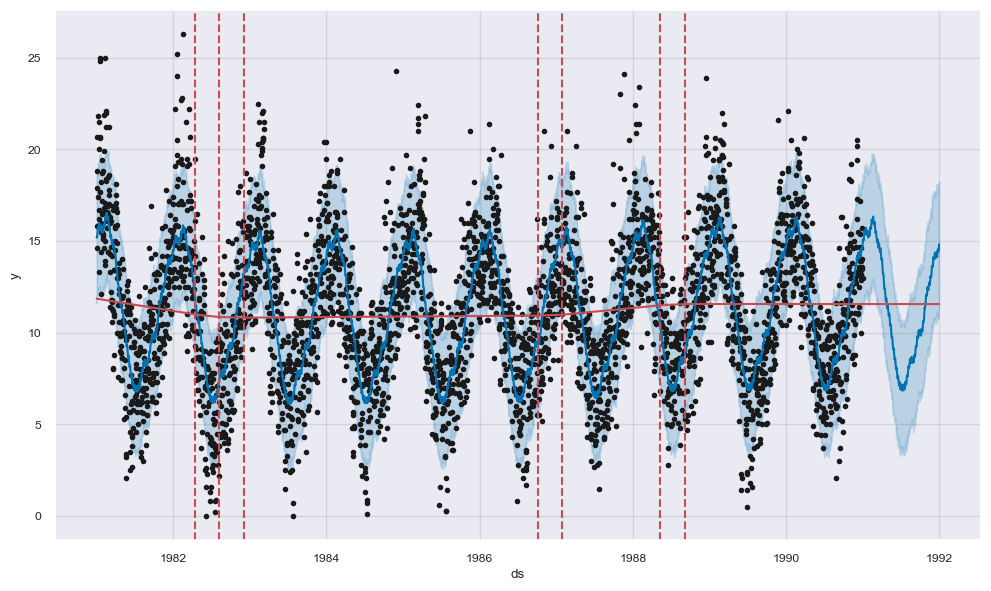

In [58]:
from prophet.plot import add_changepoints_to_plot

# plot model fitness on training data set and validation data set
fig = model.plot(forecast)
a = add_changepoints_to_plot(fig.gca(), model, forecast)


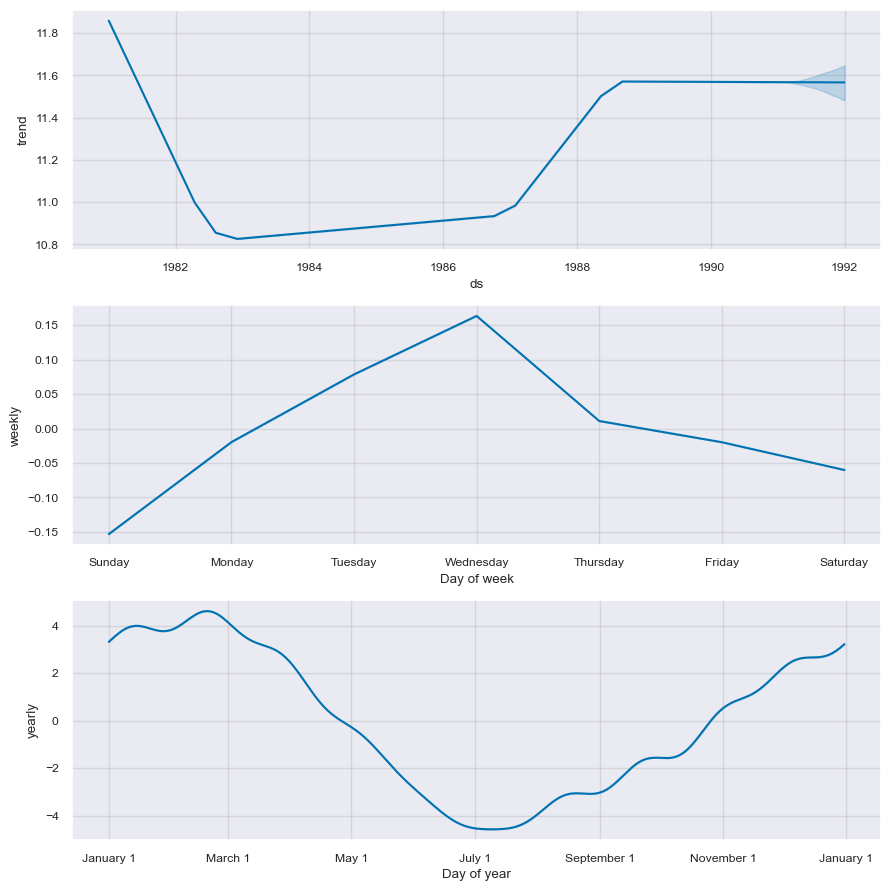

In [59]:
# plot model components
fig = model.plot_components(forecast)

17:44:20 - cmdstanpy - INFO - Chain [1] start processing
17:44:24 - cmdstanpy - INFO - Chain [1] done processing


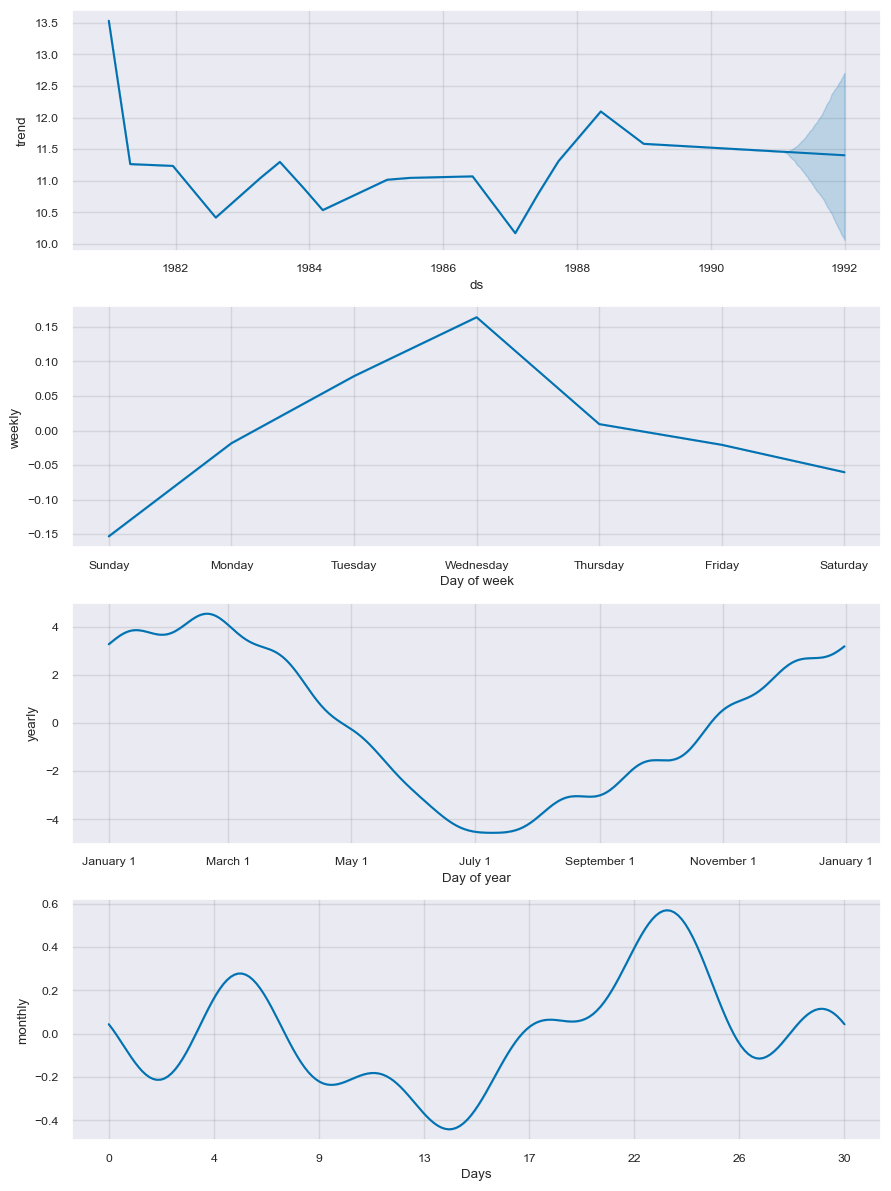

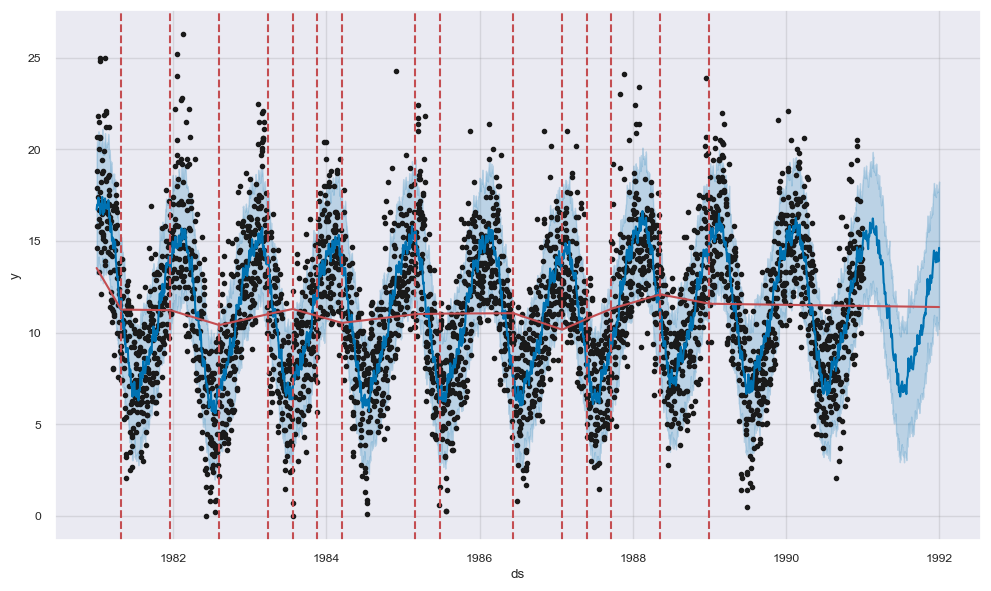

In [60]:
# model more components
model = Prophet(changepoint_prior_scale=0.5, seasonality_prior_scale=0.1, holidays_prior_scale=0.1)
model.add_seasonality(name='monthly', period=30.5, fourier_order=5)
model.fit(df)
forecast = model.make_future_dataframe(periods=365)
forecast = model.predict(forecast)
fig = model.plot_components(forecast)

# plot model fitness on training data set and validation data set
fig = model.plot(forecast)
a = add_changepoints_to_plot(fig.gca(), model, forecast)


# # interpret the output
# from prophet.diagnostics import cross_validation
# df_cv = cross_validation(model, initial='730 days', period='180 days', horizon = '365 days')
# df_cv.head()